In [ ]:
'''

mcmc == > monte carlo + markov chain

使用場合:

1. x(x1..........xn) xi間不獨立 (多維相關分布)

2. density function無法積分(缺失) (貝氏!!!!)

貝氏公式

給定觀察值 x，我們想知道隱變數 θ 的分布。貝氏公式為：

𝑝(𝜃∣𝑥) =𝑝(𝑥∣𝜃) * 𝑝(𝜃) / 𝑝(𝑥)


𝑝(𝑥) =∫𝑝(𝑥∣𝜃)𝑝(𝜃)𝑑𝜃 (積不出來) ==>  mcmc





'''

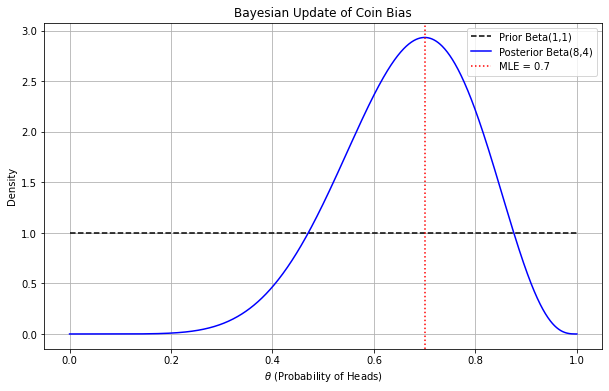

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 觀察數據
successes = 7
failures = 3
n = successes + failures

# 先驗分布：Beta(1,1) -> 均勻分布
alpha_prior = 1
beta_prior = 1

# 後驗參數：alpha_post = alpha_prior + successes
alpha_post = alpha_prior + successes
beta_post = beta_prior + failures

# θ 的範圍
theta = np.linspace(0, 1, 1000)

# 繪製分布
plt.figure(figsize=(10, 6))
plt.plot(theta, beta.pdf(theta, alpha_prior, beta_prior), 'k--', label='Prior Beta(1,1)')
plt.plot(theta, beta.pdf(theta, alpha_post, beta_post), 'b-', label=f'Posterior Beta({alpha_post},{beta_post})')
plt.axvline(successes / n, color='r', linestyle=':', label='MLE = 0.7')
plt.title('Bayesian Update of Coin Bias')
plt.xlabel(r'$\theta$ (Probability of Heads)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
'''
馬可夫鏈（Markov Chain)
隨機過程，具有「無記憶性（memoryless）」的性質。

下一步狀態只跟目前有關，跟過去的歷史無關!!

最終收斂到stationary state

P (Xn | Xn-1)

irreducible(不可約)： ❝任意兩個狀態之間，在有限步數內有正機率可以互相到達。❞

Aperiodic 不存在固定週期才會回到某狀態


轉移矩陣：
𝑃=[[0.9 0.1],
   [0.5 0.5]]

如果今天是晴天，明天有 90% 機率還是晴天、10% 機率會下雨

如果今天下雨，明天有 50% 機率晴天、50% 機率繼續下雨


π= πP,
π 0 + π 1=1 (long run propogation)


'''

In [2]:
P = np.array([
    [0.9, 0.1],
    [0.5, 0.5]
])

# 解: pi = pi @ P ⇔ pi.T 是 P.T 的特徵向量對應特徵值 λ = 1
vals, vecs = np.linalg.eig(P.T)

# 找出特徵值 ≈ 1 對應的特徵向量
i = np.argmin(np.abs(vals - 1))
pi = vecs[:, i].real
pi = pi / pi.sum()  # 正規化成機率向量

print("Stationary distribution (解析解):")
print(f"Sunny: {pi[0]:.3f}, Rainy: {pi[1]:.3f}")

Stationary distribution (解析解):
Sunny: 0.833, Rainy: 0.167


In [ ]:
'''
mcmc algo: 建立馬可夫鏈， 收斂到目標p(x)。(原本難以求得)


y1, y2.............................yn(極大)

P(yi+1 | y) = qij

最終 : 

Pi(X) == p(x) (stationary state)



重點: choose good qij (proposal) 影響收斂速度!!


step1 pick qij ， P(yn)極限分布 => P(x)

step2 simulating whole chain ，collect Yn。

mcmc很多種，差在Step 1


'''

In [ ]:
'''
HM 生多維

1. x0  n=0

2. y ~ q(x,y)

3. a(x, y) = min(1, f(y)q(yx) / f(x)q(xy))

4. U(0, 1)

5. if U <= a(x, y), xn+1 = y 。else 維持

6. n += 1

'''

In [ ]:
'''
acf檢定(x1...xn 相關性)


1. thinning (n, 2n, 3n)

2. burn in (移除前k筆)

3. multi chain

'''

In [ ]:
'''
gibbs sampler

(x, y)。 難以直接抽整體，但每個條件分布 𝑝(𝑥𝑖∣y)易於抽樣

1. use condition as q

2.never reject 。(aij不存在)


假設你有二維分布 
p(x,y)，想從它抽樣：

初始化 𝑥(0),𝑦(0)

對 𝑡=1,2,…

給y生x， 給x生y。直到收歛

𝑥(𝑡)∼𝑝(𝑥∣𝑦(𝑡−1))

𝑦(𝑡)∼𝑝(𝑦∣𝑥(𝑡)) 

n += 1

直到p(x,y)

'''

# hw1 

第一題:生成九個點(0,1)uniform點，任兩點距離不在0.1內。

演算法: step1 設定初始9個uniform(0,1)點，X1.......X9 任兩點距離不內0.1內

step2 生成u~(0,1) 設定I=int(9*u) 代表被選中的XI 。再生成一個 U~(0,1) 若 U 跟XI之外的八個點，距離皆不在0.1內。 U將取代XI。重複執行此動作。



In [5]:
import random
import numpy as np

In [6]:
# step1 設定初始九個點，任兩點距離不在0.1內。
L = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
L = np.array(L)



In [8]:
#step2
for i in range(10000000):
    u1 = random.uniform(0,1)
    
    idx = int(9 * u1) #python index 從0開始，因此I=0....8，隨機選XI
    
    u2 = random.uniform(0,1) #生成U(0,1)
    x = L[:idx]
    y = L[idx+1:]
    X = np.hstack([x, y]) #X等於XI之外，另外八個點
    arr = abs(X - u2)
    if (arr.min() > 0.1) == True: #若八個點跟U的距離最小值都大於0.1，表示所有距離都大於0.1。
        L[idx] = u2 #滿足上述條件替換XI=U

In [9]:
L #收斂至此

array([1.33486543e-01, 1.59726809e-04, 9.90058458e-01, 4.03158602e-01,
       7.78909978e-01, 8.82033807e-01, 5.25236190e-01, 2.62803072e-01,
       6.46634914e-01])

第二題 a 算 E(x1+2x2+3x3 | x1+2x2+3x3>15) x1,x2,x3 ~exp(1) 彼此獨立

#gibbs sampler


演算法: 
step1 生成第一組X1(x1 + 2x2+ 3x3) 條件為 x1+2x2+3x3>15 ,k=1

step2 I=0

step3 I=I+1

I=1 a=15-2x2-3x3 U~(0,1) x1新=-logU + a gibbs 生成新x1 用2x2,3x3當條件生，且新生成x必須滿足x1+2x2+3x3>15條件，a如果小於0表示已達成條件，set a = 0 下一個x隨便生就好 ，若a>0表示條件沒被滿足 ，下個 x 必須要 >a才行，又指數分配有遺失性，所以直接從a開始生成也合理 。

I=2 a=15-x1-3x3 U~(0,1) 2x2新= 2-logU + a (因為2x2== 2exp(1)，所以生成 2*-logU)

I=3 a=15-x1-2x2 U~(0,1) 3x3新= 3-logU + a (因為3x3== 3exp(1)，所以生成 3*-logU)

step4 得出 X2=(x1新,2x2新,3x3新) 回到step 2

step5 重複step2-4多次 得出 X1......XK K=10000

In [13]:
import numpy as np


K = 10000
samples = []

# 初始化一組合法樣本
while True:
    x1 = np.random.exponential()
    x2 = np.random.exponential()
    x3 = np.random.exponential()
    if x1 + 2*x2 + 3*x3 > 15:
        samples.append([x1, x2, x3])
        break

In [14]:
samples

[[2.2914640893710208, 0.8153880041175147, 4.373309047322707]]

In [19]:
import numpy as np

def sample_conditional_exp(a):
    u = np.random.uniform()
    return -np.log(u) + max(a, 0)

K = 10000


for _ in range(K):
    a = 15 - 2*x2 - 3*x3
    x1 = sample_conditional_exp(a)

    a = 15 - x1 - 3*x3
    x2 = sample_conditional_exp(a / 2)

    a = 15 - x1 - 2*x2
    x3 = sample_conditional_exp(a / 3)

    samples.append(x1 + 2*x2 + 3*x3)

print("Estimated conditional expectation:", np.mean(samples))

C:\Users\James\anaconda3\lib\site-packages\numpy\core\_methods.py:163: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = asanyarray(a)


Estimated conditional expectation: [9.02273895 9.02266515 9.02284304 ... 9.02327503 9.02266515 9.02284304]


In [20]:
samples

[[2.2914640893710208, 0.8153880041175147, 4.373309047322707],
 [10.308707982830958, 0.8153880041175147, 4.373309047322707],
 [14.562447215757107, 0.8153880041175147, 4.373309047322707],
 [13.574403267680648, 0.8153880041175147, 4.373309047322707],
 [14.263589614913283, 0.8153880041175147, 4.373309047322707],
 [12.342548231597961, 0.8153880041175147, 4.373309047322707],
 [13.746501985932218, 0.8153880041175147, 4.373309047322707],
 [14.545234916898904, 0.8153880041175147, 4.373309047322707],
 [15.009725474639202, 0.8153880041175147, 4.373309047322707],
 [12.744611841941916, 0.8153880041175147, 4.373309047322707],
 [14.154606224670358, 0.8153880041175147, 4.373309047322707],
 [14.278829427544899, 0.8153880041175147, 4.373309047322707],
 [15.96368000191971, 0.8153880041175147, 4.373309047322707],
 [14.752699240494538, 0.8153880041175147, 4.373309047322707],
 [13.065633531326696, 0.8153880041175147, 4.373309047322707],
 [13.529523127763202, 0.8153880041175147, 4.373309047322707],
 [12.9724

In [21]:
X = samples[2000:] #burn in 前1999筆資料


In [29]:
L = []

for i in range(len(X)):
    S = np.sum(X[i])
    L.append(S)
    
E = np.sum(L) / len(L)
print(E)

18.521110742758196
